In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datavisualisation: Florence nightingale

In [10]:
try:
    from urllib.request import Request, urlopen # Python 3
except ImportError:
    from urllib2 import Request, urlopen

req = Request("https://www.key2stats.com/Florence_Nightingale_s_data_on_deaths_from_various_causes_in_the_Crimean_War_901_76.csv")
req.add_header('User-Agent', 'Mozilla/5.0')
content = urlopen(req)

df_coxcomb = pd.read_csv(content)
df_coxcomb

,Unnamed: 0,X,Date,Month,Year,Army,Disease,Wounds,Other,Disease.rate,Wounds.rate,Other.rate
0,1,1,1854-04-01,Apr,1854,8571,1,0,5,1.4,0.0,7.0
1,2,2,1854-05-01,May,1854,23333,12,0,9,6.2,0.0,4.6
2,3,3,1854-06-01,Jun,1854,28333,11,0,6,4.7,0.0,2.5
3,4,4,1854-07-01,Jul,1854,28722,359,0,23,150.0,0.0,9.6
4,5,5,1854-08-01,Aug,1854,30246,828,1,30,328.5,0.4,11.9
5,6,6,1854-09-01,Sep,1854,30290,788,81,70,312.2,32.1,27.7
6,7,7,1854-10-01,Oct,1854,30643,503,132,128,197.0,51.7,50.1
7,8,8,1854-11-01,Nov,1854,29736,844,287,106,340.6,115.8,42.8
8,9,9,1854-12-01,Dec,1854,32779,1725,114,131,631.5,41.7,48.0
9,10,10,1855-01-01,Jan,1855,32393,2761,83,324,1022.8,30.7,120.0


In [11]:
df_coxcomb["MonthYear"] =  df_coxcomb['Month'].astype(str) + " " + df_coxcomb['Year'].astype(str)
df_coxcomb.rename(columns={"Disease": "Deaths from Preventible Disease", "Wounds": "Deaths from Wounds", "Other": "Deaths from Other Causes"}, inplace=True)
df_coxcomb["Deaths from Preventible Disease"]

0        1
1       12
2       11
3      359
4      828
5      788
6      503
7      844
8     1725
9     2761
10    2120
11    1205
12     477
13     508
14     802
15     382
16     483
17     189
18     128
19     178
20      91
21      42
22      24
23      15
Name: Deaths from Preventible Disease, dtype: int64

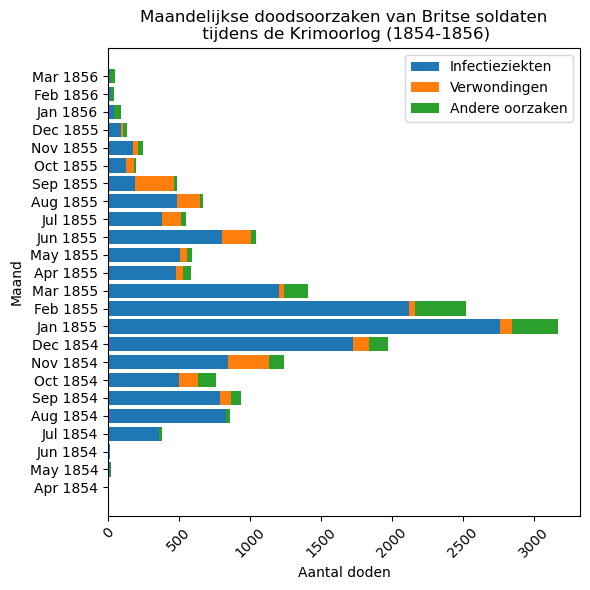

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Monthly Crimean War mortality data (approximate, widely used for teaching)
months = [
    "Apr 1854","May 1854","Jun 1854","Jul 1854","Aug 1854","Sep 1854",
    "Oct 1854","Nov 1854","Dec 1854","Jan 1855","Feb 1855","Mar 1855",
    "Apr 1855","May 1855","Jun 1855","Jul 1855","Aug 1855","Sep 1855",
    "Oct 1855","Nov 1855","Dec 1855","Jan 1856","Feb 1856","Mar 1856"
]

disease = df_coxcomb["Deaths from Preventible Disease"]
wounds = df_coxcomb["Deaths from Wounds"]
other = df_coxcomb["Deaths from Other Causes"]

df = pd.DataFrame({
    "Maand": months,
    "Infectieziekten": disease,
    "Verwondingen": wounds,
    "Andere oorzaken": other
})

# Plot stacked bar chart
plt.figure(figsize=(6, 6))
plt.barh(df["Maand"], df["Infectieziekten"], label="Infectieziekten")
plt.barh(df["Maand"], df["Verwondingen"], left=df["Infectieziekten"], label="Verwondingen")
plt.barh(
    df["Maand"],
    df["Andere oorzaken"],
    left=df["Infectieziekten"] + df["Verwondingen"],
    label="Andere oorzaken"
)

plt.ylabel("Maand")
plt.xlabel("Aantal doden")
plt.title("Maandelijkse doodsoorzaken van Britse soldaten\n tijdens de Krimoorlog (1854-1856)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig("./Figures/stacked_barchart_florence_nightingale.png")


# Unit readiness levels

In [15]:
df = pd.read_csv("./datasets/unit_readiness_levels.csv")

df_reduced = df[["type_eenheid", "personeelssterkte_pct", "opleiding_voltooid_pct", "materieel_beschikbaarheid_pct", "onderhoud_status", "logistiek_niveau", "inzetstatus", "gereedheid_H1_score"]].head()
df_reduced.reset_index(drop=True, inplace=True)
df_reduced

,type_eenheid,personeelssterkte_pct,opleiding_voltooid_pct,materieel_beschikbaarheid_pct,onderhoud_status,logistiek_niveau,inzetstatus,gereedheid_H1_score
0,Infanterie,92,88,85,Goed,Hoog,Stand-by,86
1,Artillerie,85,82,80,Goed,Medium,Stand-by,80
2,Genie,78,75,70,Matig,Medium,Inzet,70
3,Luchtmobiel,90,90,88,Onvoldoende,Hoog,Stand-by,85
4,Logistiek,95,92,93,Uitstekend,Hoog,Reserve,92


# Frequentietabel

In [17]:
# Frequentietabel
frequentie = df["onderhoud_status"].value_counts()
print(frequentie)

onderhoud_status
Goed           43
Uitstekend     39
Matig          27
Onvoldoende    16
Name: count, dtype: int64


# Kruistabel

In [19]:
kruistabel_inzet = pd.crosstab(
    df["type_eenheid"],
    df["onderhoud_status"]
)

print(kruistabel_inzet)

onderhoud_status     Goed  Matig  Onvoldoende  Uitstekend
type_eenheid                                             
Artillerie              9     10            3           0
Geneeskundige keten     0      0            0          20
Genie                   7     10            3           0
Infanterie             12      7            4           0
Logistiek               0      0            1          19
Luchtmobiel            15      0            5           0


# Staafdiagram

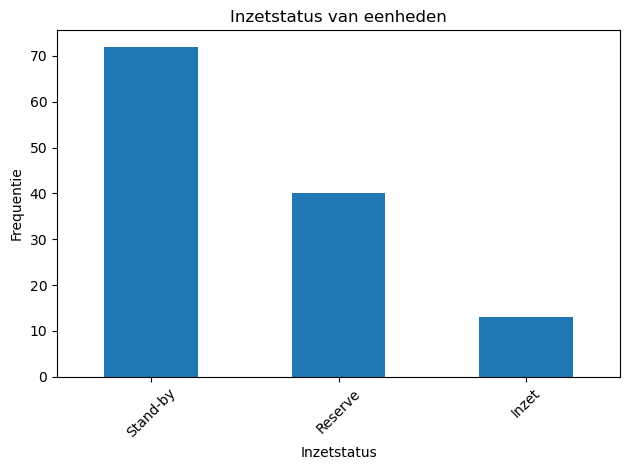

In [21]:
# Dataset inlezen
df = pd.read_csv("./datasets/unit_readiness_levels.csv")

# Frequenties tellen
frequenties = df["inzetstatus"].value_counts()

# Staafdiagram
plt.figure()
frequenties.plot(kind="bar")
plt.xlabel("Inzetstatus")
plt.ylabel("Frequentie")
plt.title("Inzetstatus van eenheden")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("./Figures/staafdiagram.png")

# Cirkeldiagram

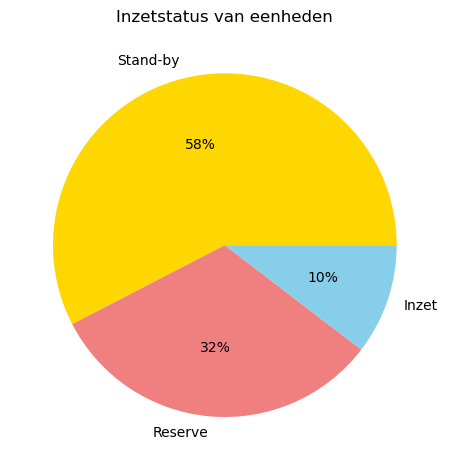

In [23]:
# --------------------------------------------------
# Pie chart: Inzetstatus
# --------------------------------------------------
deploy_counts = df["inzetstatus"].value_counts()
plt.figure()
plt.pie(deploy_counts, labels=deploy_counts.index, autopct="%1.0f%%", colors=["gold","lightcoral","skyblue"])
plt.title("Inzetstatus van eenheden")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./Figures/cirkeldiagram.png")

# Gestapelde staafdiagram

<Figure size 640x480 with 0 Axes>

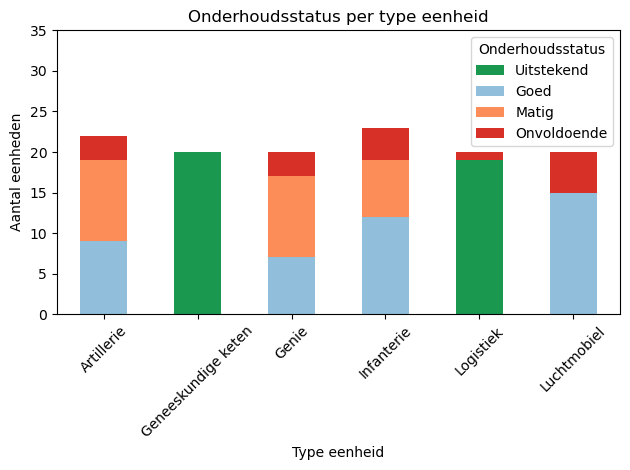

In [54]:
# Dataset inlezen
df = pd.read_csv("./datasets/unit_readiness_levels.csv")

# Kruistabel maken
kruistabel_onderhoud = pd.crosstab(
    df["type_eenheid"],
    df["onderhoud_status"]
)

# Logische volgorde van onderhoudsstatus
kleuren = {
    "Uitstekend": "#1a9850",   # groen
    "Goed": "#91bfdb",         # lichtblauw
    "Matig": "#fc8d59",        # oranje
    "Onvoldoende": "#d73027"   # rood
}

kruistabel_onderhoud = kruistabel_onderhoud[kleuren.keys()]

# Gestapeld staafdiagram
plt.figure()
kruistabel_onderhoud.plot(
    kind="bar",
    stacked=True,
    color=[kleuren[k] for k in kruistabel_onderhoud.columns]
)

plt.xlabel("Type eenheid")
plt.ylabel("Aantal eenheden")
plt.title("Onderhoudsstatus per type eenheid")
plt.legend(title="Onderhoudsstatus")
plt.xticks(rotation=45)
plt.ylim(top=35)
plt.tight_layout()
plt.savefig("./Figures/gestapelde_staafdiagram.png")

# Histogram

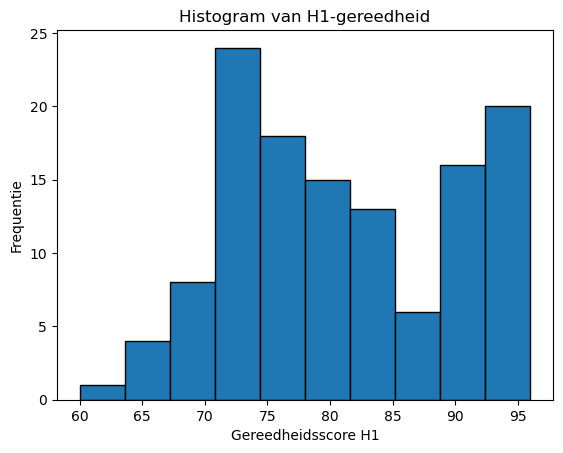

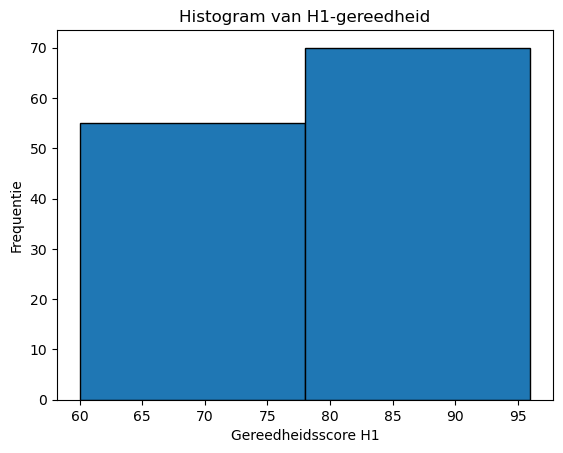

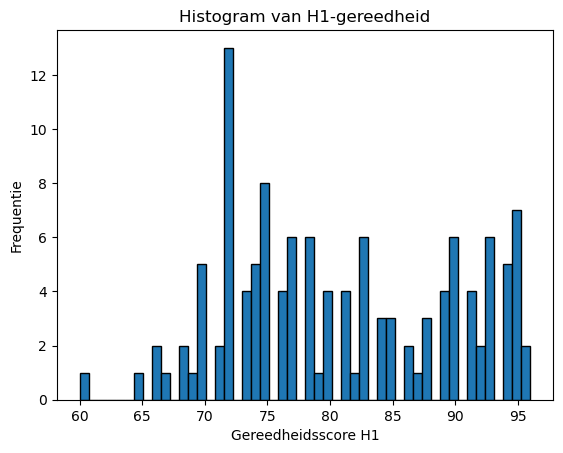

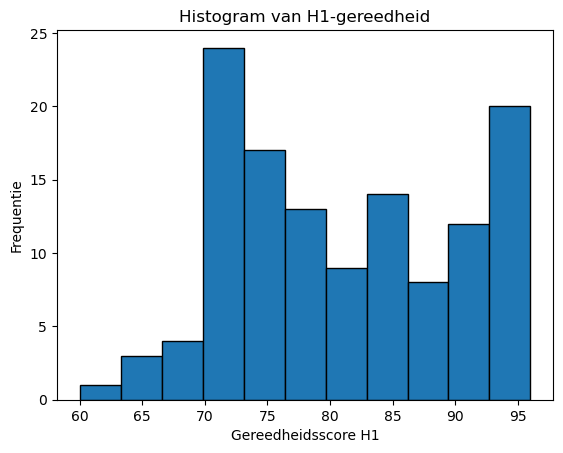

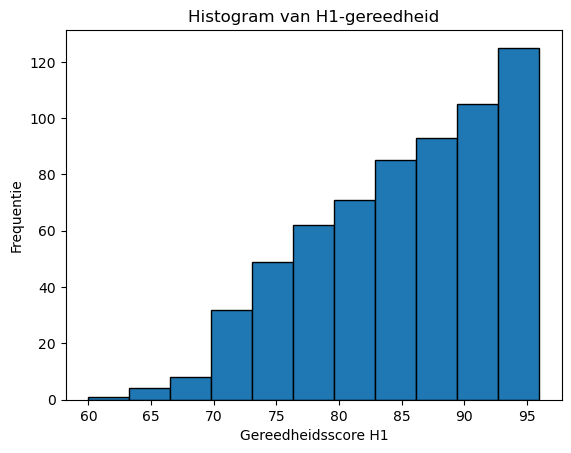

In [69]:
# Dataset inlezen
df = pd.read_csv("./datasets/unit_readiness_levels.csv")

scores = df["gereedheid_H1_score"]
relative_cumulative_scores = scores.cumsum() / scores.sum()

plt.figure()
plt.hist(scores, bins=10, edgecolor="black", linewidth=1)
plt.xlabel("Gereedheidsscore H1")
plt.ylabel("Frequentie")
plt.title("Histogram van H1-gereedheid")
plt.savefig("./Figures/histogram.png")

# Te weinig bins
plt.figure()
plt.hist(scores, bins=2, edgecolor="black", linewidth=1)
plt.xlabel("Gereedheidsscore H1")
plt.ylabel("Frequentie")
plt.title("Histogram van H1-gereedheid")
plt.savefig("./Figures/histogram_toofew.png")

# Te veel bins
plt.figure()
plt.hist(scores, bins=50, edgecolor="black", linewidth=1)
plt.xlabel("Gereedheidsscore H1")
plt.ylabel("Frequentie")
plt.title("Histogram van H1-gereedheid")
plt.savefig("./Figures/histogram_toomany.png")

# Just right
plt.figure()
plt.hist(scores, bins=int(np.sqrt(df.shape[0])), edgecolor="black", linewidth=1)
plt.xlabel("Gereedheidsscore H1")
plt.ylabel("Frequentie")
plt.title("Histogram van H1-gereedheid")
plt.savefig("./Figures/histogram_justright.png")

# Cumulative histogram
plt.figure()
plt.hist(scores, bins=int(np.sqrt(df.shape[0])), cumulative=True, edgecolor="black", linewidth=1)
plt.xlabel("Gereedheidsscore H1")
plt.ylabel("Frequentie")
plt.title("Histogram van H1-gereedheid")
plt.savefig("./Figures/cumulative_justright.png")


In [73]:
# Define bins and labels
bins = list(range(60, 105, 5))  # 60, 65, ..., 100
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]

# Discretize scores
df["gereedheid_klasse"] = pd.cut(
    df["gereedheid_H1_score"],
    bins=bins,
    labels=labels,
    right=False  # intervals are [60–65), [65–70), ...
)

# Frequency table
frequentietabel = df["gereedheid_klasse"].value_counts().sort_index()

# Cumulatieve relatieve frequentieverdeling

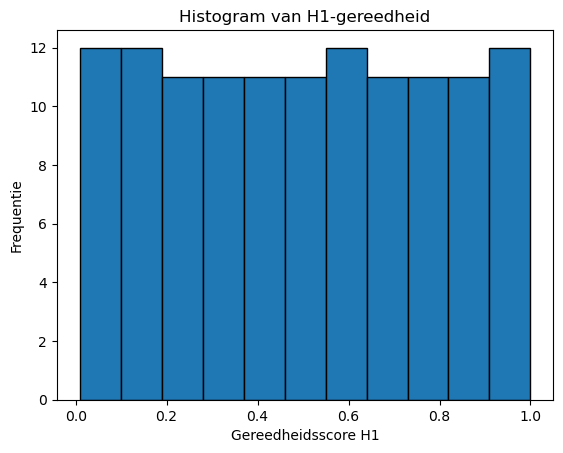

In [65]:
# Dataset inlezen
df = pd.read_csv("./datasets/unit_readiness_levels.csv")

scores = df["gereedheid_H1_score"]

# Just right
plt.figure()
plt.hist(relative_cumulative_scores, bins=int(np.sqrt(df.shape[0])), edgecolor="black", linewidth=1)
plt.xlabel("Gereedheidsscore H1")
plt.ylabel("Frequentie")
plt.title("Histogram van H1-gereedheid")
plt.savefig("./Figures/histogram_justright.png")


# Scatter plot (spreidingsdiagram)

In [ ]:
# Scatterplot
print(df)
plt.figure()
plt.scatter(
    df["opleiding_voltooid_pct"],
    df["gereedheid_H1_score"]
)

plt.xlabel("Percentage opleiding voltooid (%)")
plt.ylabel("Gereedheidsscore H1")
plt.title("Relatie tussen opleiding en gereedheid")
plt.savefig("./Figures/scatterplot.png")

In [ ]:
df[["opleiding_voltooid_pct", "gereedheid_H1_score"]]

In [ ]:
x = df["opleiding_voltooid_pct"]
y = df["gereedheid_H1_score"]

# Fit linear regression
coef = np.polyfit(x, y, 1)
lijn = np.poly1d(coef)

# Scatterplot
plt.figure()
plt.scatter(x, y, alpha=0.7)
plt.plot(x, lijn(x), color="red")

plt.xlabel("Percentage opleiding voltooid (%)")
plt.ylabel("Gereedheidsscore H1")
plt.title("Gereedheid vs. opleiding met lineaire regressielijn")
plt.savefig("./Figures/scatterplot_regression.png")

# Boxplot

In [ ]:
# Order unit types by median readiness
volgorde = list(
    df.groupby("type_eenheid")["gereedheid_H1_score"]
    .median()
    .sort_values()
    .index
)
print(volgorde)

# Group our dataset with our variable "type_eenheid"
grouped = df.groupby("type_eenheid")["gereedheid_H1_score"]

# Initialize a figure and axes
fig, ax = plt.subplots(figsize=(8,6))

# Create the boxplots with different colors for each group
boxplot = ax.boxplot(
    x=[group.values for name, group in grouped],
    labels=volgorde, 
    patch_artist=True,
    medianprops={'color': 'black'}
)

colors = [
    "#1a9850", "#66bd63", "#a6d96a",
    "#fee08b", "#fdae61", "#d73027"
]

# Assign colors to each box in the boxplot
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)

ax.set_xlabel("Type eenheid")
ax.set_ylabel("Gereedheid H1 score")
ax.set_title("Verdeling van H1-gereedheid per type eenheid")
ax.xaxis.set_ticks(ticks=[1,2,3,4,5,6], labels=volgorde[:-1] + ["Geneeskundige\nketen"])
# plt.xticks(rotation=45)
plt.tight_layout()

# Display it
plt.savefig("./Figures/boxplot.png")